# Análise de Retenção de Pacientes em uma Clínica de Nutrição

## Introdução

A retenção de pacientes é um dos principais desafios para clínicas e profissionais de nutrição. A continuidade do acompanhamento permite monitorar a evolução dos pacientes, ajustar as estratégias nutricionais e aumentar a probabilidade de alcançar os objetivos estabelecidos.

Além do impacto clínico, faltas e abandono do tratamento também podem afetar o planejamento da agenda, a produtividade dos profissionais e a receita da clínica.

Este projeto utiliza dados de pacientes, consultas, nutricionistas e pagamentos para analisar o comportamento dos pacientes ao longo do acompanhamento nutricional.

## Objetivo do projeto

O objetivo deste projeto é identificar padrões relacionados à presença, retorno e abandono dos pacientes, produzindo indicadores que possam apoiar decisões estratégicas de uma clínica de nutrição.

A análise buscará identificar fatores associados à retenção e propor ações para melhorar a continuidade do acompanhamento.

## Perguntas de negócio

O projeto pretende responder às seguintes perguntas:

* Qual é a taxa de comparecimento e de ausência nas consultas?
* Quantos pacientes retornam após a primeira consulta?
* Qual é o intervalo médio entre as consultas?
* Qual é a retenção de pacientes em 30, 60 e 90 dias?
* Quais perfis de pacientes apresentam maior taxa de retorno?
* Quais objetivos nutricionais apresentam maior retenção?
* Existem diferenças de desempenho entre os nutricionistas?
* Qual é o impacto das ausências sobre a receita da clínica?
* Quais pacientes apresentam maior risco de abandono?

## Dados utilizados

A base de dados está dividida em quatro tabelas:

* `patients`: informações demográficas e objetivo nutricional dos pacientes.
* `consultations`: histórico das consultas agendadas e realizadas.
* `nutritionists`: identificação e especialidade dos nutricionistas.
* `payments`: valor e forma de pagamento associados às consultas.

As tabelas serão inicialmente avaliadas separadamente e, posteriormente, relacionadas por meio de seus identificadores.


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [63]:
patients = pd.read_csv("data/patients.csv")
consultations = pd.read_csv("data/consultations.csv")
nutritionists = pd.read_csv("data/nutritionists.csv")
payments = pd.read_csv("data/payments.csv")

In [64]:
print("Patients:", patients.shape)
print("Consultations:", consultations.shape)
print("Nutritionists:", nutritionists.shape)
print("Payments:", payments.shape)

Patients: (100, 5)
Consultations: (386, 6)
Nutritionists: (5, 3)
Payments: (386, 4)


As bases contêm 100 pacientes, 386 consultas, 5 nutricionistas e 386 registros de pagamento. A quantidade equivalente de consultas e pagamentos
sugere uma possível relação de um pagamento para cada consulta, que será 
validada posteriormente.

## 1. Exploração inicial dos dados

Nesta etapa, serão avaliadas a estrutura das tabelas, os tipos de dados, os valores ausentes, os registros duplicados e a integridade das relações entre as tabelas.

In [65]:
tables = {
    "Patients": patients,
    "Consultations": consultations,
    "Nutritionists": nutritionists,
    "Payments": payments
}

for table_name, df in tables.items():
    print(f"\n{'=' * 50}")
    print(table_name)
    print(f"{'=' * 50}")
    display(df.head())


Patients


,patient_id,age,gender,city,goal
0,1,58,F,São Paulo,Bariátrica
1,2,33,F,Guarulhos,Emagrecimento
2,3,61,F,São Bernardo,Nutrição Esportiva
3,4,20,F,São Paulo,Diabetes
4,5,32,F,São Bernardo,Diabetes



Consultations


,consultation_id,patient_id,nutritionist_id,consultation_date,consultation_type,attended
0,1,1,3,2025-07-23,Primeira,1
1,2,1,2,2025-09-19,Retorno,1
2,3,1,5,2025-10-26,Retorno,1
3,4,2,2,2025-04-20,Primeira,1
4,5,2,1,2025-05-31,Retorno,1



Nutritionists


,nutritionist_id,name,specialty
0,1,Ana Lima,Emagrecimento
1,2,Carlos Souza,Diabetes
2,3,Fernanda Alves,Bariátrica
3,4,Marina Costa,Esportiva
4,5,Juliana Rocha,Clínica Geral



Payments


,payment_id,consultation_id,amount_brl,payment_method
0,1,1,180,PIX
1,2,2,140,Convênio
2,3,3,140,PIX
3,4,4,180,Cartão
4,5,5,140,Cartão


In [66]:
for table_name, df in tables.items():
    print(f"\n{'=' * 50}")
    print(f"Informações da tabela: {table_name}")
    print(f"{'=' * 50}")
    df.info()


Informações da tabela: Patients
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patient_id  100 non-null    int64 
 1   age         100 non-null    int64 
 2   gender      100 non-null    object
 3   city        100 non-null    object
 4   goal        100 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.0+ KB

Informações da tabela: Consultations
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386 entries, 0 to 385
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   consultation_id    386 non-null    int64 
 1   patient_id         386 non-null    int64 
 2   nutritionist_id    386 non-null    int64 
 3   consultation_date  386 non-null    object
 4   consultation_type  386 non-null    object
 5   attended           386 non-null    int64 
dtypes: int64(4)

In [67]:
quality_summary = []

for table_name, df in tables.items():
    quality_summary.append({
        "table": table_name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "null_values": df.isna().sum().sum(),
        "duplicated_rows": df.duplicated().sum()
    })

quality_summary = pd.DataFrame(quality_summary)

display(quality_summary)

,table,rows,columns,null_values,duplicated_rows
0,Patients,100,5,0,0
1,Consultations,386,6,0,0
2,Nutritionists,5,3,0,0
3,Payments,386,4,0,0


In [68]:
# Resumo da qualidade

total_nulls = quality_summary["null_values"].sum()
total_duplicates = quality_summary["duplicated_rows"].sum()

print(f"Total de valores ausentes: {total_nulls}")
print(f"Total  de linhas duplicadas: {total_duplicates}")

if total_nulls == 0 and total_duplicates == 0:
    print(
        "As tabelas não apresentam valores ausentes nem linhas "
        "completamente duplicadas."
    )
else:
    print(
        "Foram identificados valores ausentes ou registros duplicados "
        "que deverão ser analisados antes da etapa exploratória."
    )

Total de valores ausentes: 0
Total  de linhas duplicadas: 0
As tabelas não apresentam valores ausentes nem linhas completamente duplicadas.


### Conclusão da avaliação inicial

As quatro tabelas foram carregadas corretamente, totalizando 100 pacientes, 386 consultas, 5 nutricionistas e 386 registros de pagamento. Na avaliação inicial, não foram identificados valores ausentes nem linhas completamente duplicadas. Dessa forma, os dados apresentam uma boa qualidade estrutural para seguir com as etapas de tratamento, validação das chaves e análise exploratória.


## 2. Tratamento e validação dos dados

Nesta etapa, serão realizados os ajustes necessários nos tipos de dados,
a verificação de valores inválidos e a validação das chaves e relações entre
as tabelas.

In [69]:
# Conversão de dados 

consultations["consultation_date"] = pd.to_datetime(
    consultations["consultation_date"],
    errors="coerce"
)

In [70]:
# Verificar datas inválidas
print("Datas inválidas:",
    consultations["consultation_date"].isna().sum())

Datas inválidas: 0


In [71]:
# Confirmar a conversão 

print("Tipo de dado após a conversão:")
print(consultations["consultation_date"].dtype)

print("\nPeríodo dos dados:")
print("Primeira consulta:", consultations["consultation_date"].min())
print("Última consulta:", consultations["consultation_date"].max())

Tipo de dado após a conversão:
datetime64[ns]

Período dos dados:
Primeira consulta: 2025-02-03 00:00:00
Última consulta: 2026-08-07 00:00:00


> **Nota:** Os dados utilizados neste projeto são simulados e representam
> consultas registradas entre fevereiro de 2025 e agosto de 2026.

In [72]:
print("Valores encontrados em attended:")
display(
    consultations["attended"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("attended")
    .reset_index(name="consultations")
)

invalid_attended = (
    ~consultations["attended"].isin([0, 1])
).sum()

print("Valores inválidos em attended:", invalid_attended)

Valores encontrados em attended:


,attended,consultations
0,0,79
1,1,307


Valores inválidos em attended: 0


## 3. Estatísticas descritivas

As estatísticas descritivas serão aplicadas somente às variáveis numéricas
com significado analítico, evitando a interpretação de identificadores como
medidas quantitativas.

In [73]:
print("Estatísticas da idade dos pacientes")
display(patients[["age"]].describe())

print("Estatísticas dos valores das consultas")
display(payments[["amount_brl"]].describe())

Estatísticas da idade dos pacientes


,age
count,100.00
mean,45.11
std,18.07
min,18.00
25%,28.00
50%,44.00
75%,62.00
max,74.00


Estatísticas dos valores das consultas


,amount_brl
count,386.00
mean,150.36
std,17.55
min,140.00
25%,140.00
50%,140.00
75%,180.00
max,180.00


In [74]:
print("Validação das idades")
print("Idade mínima:", patients["age"].min())
print("Idade máxima:", patients["age"].max())

invalid_ages = (
    ~patients["age"].between(18, 100)
).sum()

print("Idades fora do intervalo esperado:", invalid_ages)

print("\nValidação dos pagamentos")
print(
    "Valores disponíveis:",
    sorted(payments["amount_brl"].unique())
)

invalid_payments = (
    payments["amount_brl"] <= 0
).sum()

print(
    "Pagamentos iguais ou menores que zero:",
    invalid_payments
)

Validação das idades
Idade mínima: 18
Idade máxima: 74
Idades fora do intervalo esperado: 0

Validação dos pagamentos
Valores disponíveis: [140, 180]
Pagamentos iguais ou menores que zero: 0


### Conclusão das estatísticas descritivas

Os pacientes apresentam idades entre 18 e 74 anos, com média de 45,11 anos
e mediana de 44 anos. Não foram identificadas idades fora do intervalo
esperado para a população analisada.

Os valores registrados para as consultas variam entre R$ 140 e R$ 180,
com média de R$ 150,36 e mediana de R$ 140. Não foram encontrados pagamentos
iguais ou menores que zero.

Foram identificados apenas dois valores distintos de pagamento. Posteriormente,
será verificado se essa diferença está relacionada ao tipo de consulta ou a
outra característica do atendimento.

## 4. Análise das variáveis categóricas

Nesta etapa, serão avaliadas as categorias presentes nas tabelas para
identificar possíveis diferenças de escrita, categorias duplicadas ou
valores inesperados.

In [75]:
categorical_columns = {
    "gender": patients["gender"],
    "city": patients["city"],
    "goal": patients["goal"],
    "consultation_type": consultations["consultation_type"],
    "specialty": nutritionists["specialty"],
    "payment_method": payments["payment_method"]
}

for column_name, series in categorical_columns.items():
    print(f"\n{'=' * 40}")
    print(column_name)
    print(f"{'=' * 40}")

    category_summary = (
        series
        .value_counts(dropna=False)
        .rename_axis(column_name)
        .reset_index(name="count")
    )

    display(category_summary)


gender


,gender,count
0,F,56
1,M,44



city


,city,count
0,São Paulo,26
1,São Bernardo,22
2,Guarulhos,19
3,Osasco,18
4,Santo André,15



goal


...

,consultation_type,count
0,Retorno,286
1,Primeira,100



specialty


,specialty,count
0,Emagrecimento,1
1,Diabetes,1
2,Bariátrica,1
3,Esportiva,1
4,Clínica Geral,1



payment_method


,payment_method,count
0,Cartão,137
1,PIX,126
2,Convênio,123


## 5. Validação das chaves primárias

Além das linhas completamente duplicadas, será verificado se os
identificadores definidos como chaves primárias aparecem mais de uma vez
em cada tabela.

In [76]:
key_validation = pd.DataFrame({
    "table": [
        "Patients",
        "Consultations",
        "Nutritionists",
        "Payments"
    ],
    "primary_key": [
        "patient_id",
        "consultation_id",
        "nutritionist_id",
        "payment_id"
    ],
    "duplicated_keys": [
        patients["patient_id"].duplicated().sum(),
        consultations["consultation_id"].duplicated().sum(),
        nutritionists["nutritionist_id"].duplicated().sum(),
        payments["payment_id"].duplicated().sum()
    ]
})

display(key_validation)

,table,primary_key,duplicated_keys
0,Patients,patient_id,0
1,Consultations,consultation_id,0
2,Nutritionists,nutritionist_id,0
3,Payments,payment_id,0


## 6. Validação das relações entre as tabelas

Será verificado se todas as chaves estrangeiras possuem correspondência nas
tabelas de origem e se cada consulta possui um pagamento associado.

In [77]:
# Validar a integridade referencial dos dados

relationship_validation = pd.DataFrame({
    "validation": [
        "Consultas com patient_id inexistente",
        "Consultas com nutritionist_id inexistente",
        "Pagamentos com consultation_id inexistente",
        "Consultas sem pagamento associado"
    ],
    "invalid_records": [
        (
            ~consultations["patient_id"]
            .isin(patients["patient_id"])
        ).sum(),

        (
            ~consultations["nutritionist_id"]
            .isin(nutritionists["nutritionist_id"])
        ).sum(),

        (
            ~payments["consultation_id"]
            .isin(consultations["consultation_id"])
        ).sum(),

        (
            ~consultations["consultation_id"]
            .isin(payments["consultation_id"])
        ).sum()
    ]
})

display(relationship_validation)

,validation,invalid_records
0,Consultas com patient_id inexistente,0
1,Consultas com nutritionist_id inexistente,0
2,Pagamentos com consultation_id inexistente,0
3,Consultas sem pagamento associado,0


In [78]:
# Validar relação consulta-pago

consultation_payment_validation = pd.DataFrame({
    "indicator": [
        "Total de consultas",
        "Total de pagamentos",
        "Consultation IDs duplicados em payments",
        "Consultas sem pagamento"
    ],
    "value": [
        consultations["consultation_id"].nunique(),
        payments["consultation_id"].nunique(),
        payments["consultation_id"].duplicated().sum(),
        (
            ~consultations["consultation_id"]
            .isin(payments["consultation_id"])
        ).sum()
    ]
})

display(consultation_payment_validation)

,indicator,value
0,Total de consultas,386
1,Total de pagamentos,386
2,Consultation IDs duplicados em payments,0
3,Consultas sem pagamento,0


## Conclusão da preparação dos dados

As tabelas não apresentam valores ausentes, linhas completamente duplicadas
ou chaves primárias repetidas. Todas as datas foram convertidas corretamente
e a variável `attended` contém somente os valores esperados, 0 e 1.

Também não foram identificadas chaves estrangeiras sem correspondência.
Cada consulta possui um paciente, um nutricionista e um pagamento associado,
confirmando a integridade do modelo relacional.

Dessa forma, os dados estão adequados para a construção da tabela analítica
e para o início da análise exploratória.

## 7. Criação do banco de dados SQL

Após a limpeza e validação dos dados em Python, as quatro tabelas serão
armazenadas em um banco de dados SQLite.

O SQL será utilizado para consultar os dados, validar as relações entre as
tabelas e construir a tabela analítica por meio de operações `JOIN`.

In [79]:
import sqlite3
connection = sqlite3.connect("nutrition_clinic.db")

In [80]:
patients.to_sql(
    "patients",
    connection,
    if_exists="replace",
    index=False
)

consultations.to_sql(
    "consultations",
    connection,
    if_exists="replace",
    index=False
)

nutritionists.to_sql(
    "nutritionists",
    connection,
    if_exists="replace",
    index=False
)

payments.to_sql(
    "payments",
    connection,
    if_exists="replace",
    index=False
);

In [81]:
# Confirmar tabelas criadas
query_tables = """
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
"""

sql_tables = pd.read_sql_query(
    query_tables,
    connection
)

display(sql_tables)

,name
0,consultations
1,nutritionists
2,patients
3,payments


In [82]:
#Confirmar quantidade de registros 
query_counts = """
SELECT
    'patients' AS table_name,
    COUNT(*) AS total_rows
FROM patients

UNION ALL

SELECT
    'consultations',
    COUNT(*)
FROM consultations

UNION ALL

SELECT
    'nutritionists',
    COUNT(*)
FROM nutritionists

UNION ALL

SELECT
    'payments',
    COUNT(*)
FROM payments;
"""

table_counts_sql = pd.read_sql_query(
    query_counts,
    connection
)

display(table_counts_sql)

,table_name,total_rows
0,patients,100
1,consultations,386
2,nutritionists,5
3,payments,386


## 8. Construção da tabela analítica com SQL

A tabela de consultas será utilizada como base da análise, pois cada linha
representa um atendimento agendado.

Por meio de operações `LEFT JOIN`, serão adicionadas as características dos
pacientes, dos nutricionistas e dos pagamentos.

In [83]:
analytical_query = """
SELECT
    c.consultation_id,
    c.patient_id,
    c.nutritionist_id,
    c.consultation_date,
    c.consultation_type,
    c.attended,

    p.age,
    p.gender,
    p.city,
    p.goal,

    n.name AS nutritionist_name,
    n.specialty,

    pay.payment_id,
    pay.amount_brl,
    pay.payment_method

FROM consultations AS c

LEFT JOIN patients AS p
    ON c.patient_id = p.patient_id

LEFT JOIN nutritionists AS n
    ON c.nutritionist_id = n.nutritionist_id

LEFT JOIN payments AS pay
    ON c.consultation_id = pay.consultation_id;
"""

In [84]:
analytical_table = pd.read_sql_query(
    analytical_query,
    connection
)

display(analytical_table.head())

,consultation_id,patient_id,nutritionist_id,consultation_date,consultation_type,attended,age,gender,city,goal,nutritionist_name,specialty,payment_id,amount_brl,payment_method
0,1,1,3,2025-07-23 00:00:00,Primeira,1,58,F,São Paulo,Bariátrica,Fernanda Alves,Bariátrica,1,180,PIX
1,2,1,2,2025-09-19 00:00:00,Retorno,1,58,F,São Paulo,Bariátrica,Carlos Souza,Diabetes,2,140,Convênio
2,3,1,5,2025-10-26 00:00:00,Retorno,1,58,F,São Paulo,Bariátrica,Juliana Rocha,Clínica Geral,3,140,PIX
3,4,2,2,2025-04-20 00:00:00,Primeira,1,33,F,Guarulhos,Emagrecimento,Carlos Souza,Diabetes,4,180,Cartão
4,5,2,1,2025-05-31 00:00:00,Retorno,1,33,F,Guarulhos,Emagrecimento,Ana Lima,Emagrecimento,5,140,Cartão


In [85]:
print("Dimensão da tabela analítica:",
    analytical_table.shape)

Dimensão da tabela analítica: (386, 15)


In [86]:
# Converter o tipo de data
analytical_table["consultation_date"] = pd.to_datetime(
    analytical_table["consultation_date"],
    errors="coerce"
)
analytical_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386 entries, 0 to 385
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   consultation_id    386 non-null    int64         
 1   patient_id         386 non-null    int64         
 2   nutritionist_id    386 non-null    int64         
 3   consultation_date  386 non-null    datetime64[ns]
 4   consultation_type  386 non-null    object        
 5   attended           386 non-null    int64         
 6   age                386 non-null    int64         
 7   gender             386 non-null    object        
 8   city               386 non-null    object        
 9   goal               386 non-null    object        
 10  nutritionist_name  386 non-null    object        
 11  specialty          386 non-null    object        
 12  payment_id         386 non-null    int64         
 13  amount_brl         386 non-null    int64         
 14  payment_me

In [87]:
# Validação das relações utilizando SQL

sql_relationship_validation_query = """
SELECT
    (
        SELECT COUNT(*)
        FROM consultations AS c
        LEFT JOIN patients AS p
            ON c.patient_id = p.patient_id
        WHERE p.patient_id IS NULL
    ) AS consultations_without_patient,

    (
        SELECT COUNT(*)
        FROM consultations AS c
        LEFT JOIN nutritionists AS n
            ON c.nutritionist_id = n.nutritionist_id
        WHERE n.nutritionist_id IS NULL
    ) AS consultations_without_nutritionist,

    (
        SELECT COUNT(*)
        FROM consultations AS c
        LEFT JOIN payments AS p
            ON c.consultation_id = p.consultation_id
        WHERE p.payment_id IS NULL
    ) AS consultations_without_payment;
"""

sql_relationship_validation = pd.read_sql_query(
    sql_relationship_validation_query,
    connection
)

display(sql_relationship_validation)

,consultations_without_patient,consultations_without_nutritionist,consultations_without_payment
0,0,0,0


## 9. Validação da tabela analítica

Após a construção da tabela analítica com SQL, será verificado se os registros
originais foram preservados e se a operação de `LEFT JOIN` gerou valores
ausentes ou duplicidades.

In [88]:
analytical_validation = pd.DataFrame({
    "indicator": [
        "Linhas na tabela analítica",
        "Colunas na tabela analítica",
        "Consultas únicas",
        "Pacientes únicos",
        "Nutricionistas únicos",
        "Pagamentos únicos",
        "Valores ausentes",
        "Linhas duplicadas",
        "Consultation IDs duplicados",
        "Datas inválidas"
    ],
    "value": [
        analytical_table.shape[0],
        analytical_table.shape[1],
        analytical_table["consultation_id"].nunique(),
        analytical_table["patient_id"].nunique(),
        analytical_table["nutritionist_id"].nunique(),
        analytical_table["payment_id"].nunique(),
        analytical_table.isna().sum().sum(),
        analytical_table.duplicated().sum(),
        analytical_table["consultation_id"].duplicated().sum(),
        analytical_table["consultation_date"].isna().sum()
    ]
})

display(analytical_validation)

,indicator,value
0,Linhas na tabela analítica,386
1,Colunas na tabela analítica,15
2,Consultas únicas,386
3,Pacientes únicos,100
4,Nutricionistas únicos,5
5,Pagamentos únicos,386
6,Valores ausentes,0
7,Linhas duplicadas,0
8,Consultation IDs duplicados,0
9,Datas inválidas,0


### Conclusão da construção da tabela analítica

A operação de `LEFT JOIN` realizada em SQL preservou os 386 registros de
consulta, os 100 pacientes, os 5 nutricionistas e os 386 pagamentos presentes
nas tabelas originais.

Não foram identificados valores ausentes, registros duplicados,
identificadores de consulta repetidos ou datas inválidas. Dessa forma, a
tabela analítica foi construída corretamente e está adequada para o
desenvolvimento das análises de comparecimento, receita e retenção.

## 10. Análise exploratória e indicadores de negócio

Após a validação da tabela analítica, serão calculados os principais
indicadores relacionados ao comparecimento, à frequência das consultas
e à receita registrada pela clínica.

### 10.1 Taxa de comparecimento

In [89]:
#Taxa de comparecimento

attendance_query = """
SELECT
    COUNT(*) AS total_consultations,
    SUM(attended) AS attended_consultations,
    COUNT(*) - SUM(attended) AS missed_consultations,
    ROUND(100.0 * SUM(attended) / COUNT(*),
        2
    ) AS attendance_rate
FROM consultations;
"""

attendance_sql = pd.read_sql_query(
    attendance_query,
    connection
)

display(attendance_sql)

,total_consultations,attended_consultations,missed_consultations,attendance_rate
0,386,307,79,79.53


### 10.2 Consultas por paciente

In [90]:
#Consultas por paciente

consultations_per_patient_query = """
SELECT
    patient_id,
    COUNT(*) AS total_consultations,
    SUM(attended) AS attended_consultations
FROM consultations
GROUP BY patient_id
ORDER BY total_consultations DESC;
"""

consultations_per_patient = pd.read_sql_query(
    consultations_per_patient_query,
    connection
)

display(consultations_per_patient.head())

,patient_id,total_consultations,attended_consultations
0,100,6,5
1,97,6,5
2,95,6,4
3,84,6,6
4,81,6,4


### 10.3 Receita por método de pagamento

In [91]:
#Receita por método de pagamento
revenue_by_payment_query = """
SELECT
    payment_method,
    COUNT(*) AS total_payments,
    SUM(amount_brl) AS total_revenue,
    ROUND(AVG(amount_brl), 2) AS average_payment
FROM payments
GROUP BY payment_method
ORDER BY total_revenue DESC;
"""

revenue_by_payment = pd.read_sql_query(
    revenue_by_payment_query,
    connection
)

display(revenue_by_payment)

,payment_method,total_payments,total_revenue,average_payment
0,Cartão,137,20540,149.93
1,PIX,126,19120,151.75
2,Convênio,123,18380,149.43


### 10.4 Receita segundo o comparecimento

In [92]:
#Receita por status de comparecimento

revenue_by_attendance_query = """
SELECT
    CASE
        WHEN c.attended = 1 THEN 'Compareceu'
        ELSE 'Não compareceu'
    END AS attendance_status,
    COUNT(*) AS total_consultations,
    SUM(p.amount_brl) AS total_revenue,
    ROUND(AVG(p.amount_brl), 2) AS average_payment
FROM consultations AS c

LEFT JOIN payments AS p
    ON c.consultation_id = p.consultation_id

GROUP BY c.attended
ORDER BY c.attended DESC;
"""

revenue_by_attendance = pd.read_sql_query(
    revenue_by_attendance_query,
    connection
)

display(revenue_by_attendance)

,attendance_status,total_consultations,total_revenue,average_payment
0,Compareceu,307,46100,150.16
1,Não compareceu,79,11940,151.14


### 10.5 Receita por método e comparecimento

In [93]:
#Receita por método de pagamento e comparecimento

revenue_method_attendance_query = """
SELECT
    p.payment_method,
    CASE
        WHEN c.attended = 1 THEN 'Compareceu'
        ELSE 'Não compareceu'
    END AS attendance_status,
    COUNT(*) AS total_consultations,
    SUM(p.amount_brl) AS total_revenue
FROM consultations AS c

LEFT JOIN payments AS p
    ON c.consultation_id = p.consultation_id

GROUP BY
    p.payment_method,
    c.attended

ORDER BY
    p.payment_method,
    c.attended DESC;
"""

revenue_method_attendance = pd.read_sql_query(
    revenue_method_attendance_query,
    connection
)

display(revenue_method_attendance)

,payment_method,attendance_status,total_consultations,total_revenue
0,Cartão,Compareceu,109,16300
1,Cartão,Não compareceu,28,4240
2,Convênio,Compareceu,98,14520
3,Convênio,Não compareceu,25,3860
4,PIX,Compareceu,100,15280
5,PIX,Não compareceu,26,3840


In [94]:
#Preparacao dos dados para o gráfico
revenue_plot = revenue_method_attendance.pivot(
    index="payment_method",
    columns="attendance_status",
    values="total_revenue"
).fillna(0)

# Organiza as colunas na ordem desejada
column_order = [
    column
    for column in ["Compareceu", "Não compareceu"]
    if column in revenue_plot.columns
]

revenue_plot = revenue_plot[column_order]

display(revenue_plot)

attendance_status,Compareceu,Não compareceu
payment_method,,
Cartão,16300,4240
Convênio,14520,3860
PIX,15280,3840


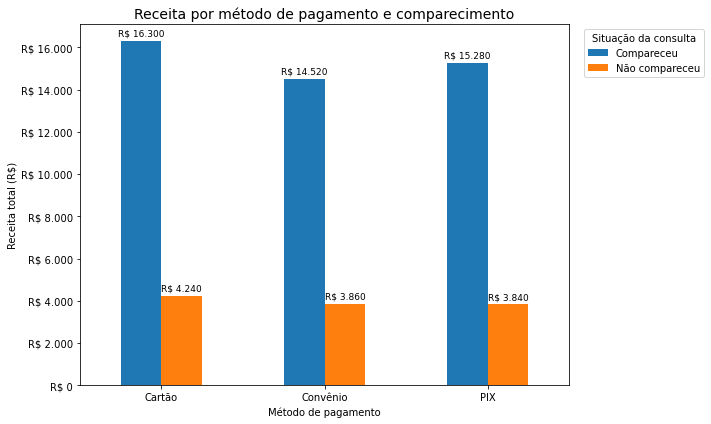

In [95]:
from matplotlib.ticker import FuncFormatter

def format_brl(value):
    return f"R$ {value:,.0f}".replace(",", ".")

ax = revenue_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Receita por método de pagamento e comparecimento",
    fontsize=14
)

ax.set_xlabel("Método de pagamento")
ax.set_ylabel("Receita total (R$)")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: format_brl(value)
    )
)

ax.legend(
    title="Situação da consulta",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

for container in ax.containers:
    labels = [
        format_brl(bar.get_height())
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [96]:
#Calcular percentuais para interpretar o gráfico

revenue_attendance_summary = (
    revenue_method_attendance
    .groupby(
        "attendance_status",
        as_index=False
    )["total_revenue"]
    .sum()
)

revenue_attendance_summary["percentage"] = (
    revenue_attendance_summary["total_revenue"]
    / revenue_attendance_summary["total_revenue"].sum()
    * 100
).round(2)

display(revenue_attendance_summary)

,attendance_status,total_revenue,percentage
0,Compareceu,46100,79.43
1,Não compareceu,11940,20.57


### Conclusão da análise da receita

A clínica registrou uma receita total de R\$ 58.040 no período analisado.

O Cartão apresentou a maior participação, com R\$ 20.540, seguido pelo PIX, com R\$ 19.120, e pelo Convênio, com R\$ 18.380.

As consultas com comparecimento representam R\$ 46.100, equivalentes a 79,43\% do valor total registrado. As consultas sem comparecimento estão associadas a R\$ 11.940, correspondendo a 20,57\%.

A distribuição da receita entre os métodos de pagamento é relativamente equilibrada. Entretanto, aproximadamente um quinto do valor registrado está associado a consultas não realizadas, resultado relevante para a gestão da agenda e das políticas de cancelamento.

Como existe um pagamento associado a todas as consultas, os valores das ausências não devem ser interpretados automaticamente como perda financeira. A base não informa se esses valores foram cobrados, reembolsados ou somente registrados.


## 11. Análise de retenção dos pacientes

A retenção será avaliada considerando apenas os pacientes que compareceram
à primeira consulta, pois esses pacientes efetivamente iniciaram o
acompanhamento nutricional.

Será considerado retido o paciente que realizou pelo menos uma consulta de
retorno após a primeira consulta atendida.

As taxas serão calculadas de forma acumulada:

- Retenção em 30 dias: primeiro retorno realizado em até 30 dias;
- Retenção em 60 dias: primeiro retorno realizado em até 60 dias;
- Retenção em 90 dias: primeiro retorno realizado em até 90 dias.

Pacientes que não compareceram à primeira consulta não serão incluídos no
denominador da taxa de retenção.

In [97]:
# Calcular o primeiro retorno com SQL

patient_retention_query = """
WITH first_consultation AS (
    SELECT
        patient_id,
        MIN(DATE(consultation_date)) AS first_consultation_date
    FROM consultations
    WHERE consultation_type = 'Primeira'
      AND attended = 1
    GROUP BY patient_id
),

first_return AS (
    SELECT
        c.patient_id,
        MIN(DATE(c.consultation_date)) AS first_return_date
    FROM consultations AS c

    INNER JOIN first_consultation AS f
        ON c.patient_id = f.patient_id

    WHERE c.consultation_type = 'Retorno'
      AND c.attended = 1
      AND DATE(c.consultation_date) >
          DATE(f.first_consultation_date)

    GROUP BY c.patient_id
),

retention_base AS (
    SELECT
        f.patient_id,
        f.first_consultation_date,
        r.first_return_date,

        CAST(
            JULIANDAY(r.first_return_date)
            - JULIANDAY(f.first_consultation_date)
            AS INTEGER
        ) AS days_to_first_return

    FROM first_consultation AS f

    LEFT JOIN first_return AS r
        ON f.patient_id = r.patient_id
)

SELECT
    patient_id,
    first_consultation_date,
    first_return_date,
    days_to_first_return,

    CASE
        WHEN days_to_first_return BETWEEN 1 AND 30
        THEN 1
        ELSE 0
    END AS retained_30_days,

    CASE
        WHEN days_to_first_return BETWEEN 1 AND 60
        THEN 1
        ELSE 0
    END AS retained_60_days,

    CASE
        WHEN days_to_first_return BETWEEN 1 AND 90
        THEN 1
        ELSE 0
    END AS retained_90_days

FROM retention_base

ORDER BY patient_id;
"""

patient_retention = pd.read_sql_query(
    patient_retention_query,
    connection
)

display(patient_retention.head(10))

,patient_id,first_consultation_date,first_return_date,days_to_first_return,retained_30_days,retained_60_days,retained_90_days
0,1,2025-07-23,2025-09-19,58.00,0,1,1
1,2,2025-04-20,2025-05-31,41.00,0,1,1
2,3,2025-05-27,2025-06-25,29.00,1,1,1
3,4,2025-05-19,2025-06-07,19.00,1,1,1
4,5,2025-04-19,None,NaN,0,0,0
5,7,2025-08-12,2025-09-15,34.00,0,1,1
6,9,2025-09-25,2025-11-11,47.00,0,1,1
7,10,2025-11-28,2026-01-22,55.00,0,1,1
8,11,2026-01-03,2026-04-16,103.00,0,0,0
9,13,2025-12-17,2026-01-05,19.00,1,1,1


### Validação do período disponível para acompanhamento

Para que as taxas de retenção sejam reproduzíveis, as datas da base de retenção
serão convertidas explicitamente e será calculado o número de dias disponíveis
entre a primeira consulta atendida e a última data presente na base.

Essa variável permite verificar se cada paciente teve tempo suficiente para
completar as janelas de 30, 60 e 90 dias.


In [98]:
# Converter as datas da base de retenção
patient_retention["first_consultation_date"] = pd.to_datetime(
    patient_retention["first_consultation_date"],
    errors="coerce"
)

patient_retention["first_return_date"] = pd.to_datetime(
    patient_retention["first_return_date"],
    errors="coerce"
)

# Utilizar a última data disponível na base como encerramento da observação
data_end_date = consultations["consultation_date"].max()

patient_retention["available_follow_up_days"] = (
    data_end_date
    - patient_retention["first_consultation_date"]
).dt.days

print("Data final da base:", data_end_date.date())
print(
    "Pacientes sem data válida de primeira consulta:",
    patient_retention["first_consultation_date"].isna().sum()
)
print(
    "Menor período disponível para acompanhamento:",
    patient_retention["available_follow_up_days"].min(),
    "dias"
)

display(
    patient_retention[
        [
            "patient_id",
            "first_consultation_date",
            "first_return_date",
            "days_to_first_return",
            "available_follow_up_days"
        ]
    ].head()
)


Data final da base: 2026-08-07
Pacientes sem data válida de primeira consulta: 0
Menor período disponível para acompanhamento: 175 dias


,patient_id,first_consultation_date,first_return_date,days_to_first_return,available_follow_up_days
0,1,2025-07-23,2025-09-19,58.00,380
1,2,2025-04-20,2025-05-31,41.00,474
2,3,2025-05-27,2025-06-25,29.00,437
3,4,2025-05-19,2025-06-07,19.00,445
4,5,2025-04-19,NaT,NaN,475


In [99]:
# Validar os resultados 
print(
    "Pacientes com primeira consulta atendida:",
    patient_retention["patient_id"].nunique()
)

print(
    "Pacientes com retorno atendido:",
    patient_retention["first_return_date"].notna().sum()
)

print(
    "Pacientes sem retorno atendido:",
    patient_retention["first_return_date"].isna().sum()
)

print(
    "Patient IDs duplicados:",
    patient_retention["patient_id"].duplicated().sum()
)

Pacientes com primeira consulta atendida: 78
Pacientes com retorno atendido: 69
Pacientes sem retorno atendido: 9
Patient IDs duplicados: 0


In [100]:
# Validar retornos anteriores o realizados o mesmo día
invalid_return_intervals = (
    patient_retention["days_to_first_return"]
    .dropna()
    .le(0)
    .sum()
)

print(
    "Intervalos inválidos até o primeiro retorno:",
    invalid_return_intervals
)

Intervalos inválidos até o primeiro retorno: 0


In [101]:
# Cálculo da taxa de retenção

eligible_patients = patient_retention["patient_id"].nunique()

retained_30 = patient_retention["retained_30_days"].sum()
retained_60 = patient_retention["retained_60_days"].sum()
retained_90 = patient_retention["retained_90_days"].sum()

retention_summary = pd.DataFrame({
    "period": [
        "30 dias",
        "60 dias",
        "90 dias"
    ],
    "retained_patients": [
        retained_30,
        retained_60,
        retained_90
    ]
})

retention_summary["eligible_patients"] = eligible_patients

retention_summary["retention_rate"] = (
    retention_summary["retained_patients"]
    / retention_summary["eligible_patients"]
    * 100
).round(2)

display(retention_summary)

,period,retained_patients,eligible_patients,retention_rate
0,30 dias,20,78,25.64
1,60 dias,59,78,75.64
2,90 dias,64,78,82.05


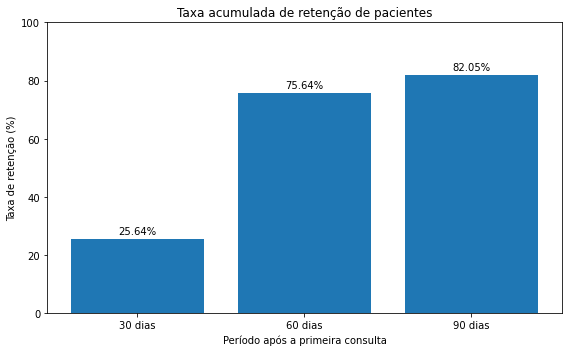

In [102]:
# Gráfico de retenção
fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars = ax.bar(
    retention_summary["period"],
    retention_summary["retention_rate"]
)

ax.set_title(
    "Taxa acumulada de retenção de pacientes"
)

ax.set_xlabel(
    "Período após a primeira consulta"
)

ax.set_ylabel(
    "Taxa de retenção (%)"
)

ax.set_ylim(
    0,
    max(
        100,
        retention_summary["retention_rate"].max() + 10
    )
)

for bar, rate in zip(
    bars,
    retention_summary["retention_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [103]:
# Distribuição dos dias até o retorno
return_time_summary = (
    patient_retention["days_to_first_return"]
    .dropna()
    .describe()
)

display(
    return_time_summary.to_frame(
        name="days_to_first_return"
    )
)
print(
    "Tempo médio até o primeiro retorno:",
    round(
        patient_retention[
            "days_to_first_return"
        ].mean(),
        2
    ),
    "dias"
)

print(
    "Tempo mediano até o primeiro retorno:",
    round(
        patient_retention[
            "days_to_first_return"
        ].median(),
        2
    ),
    "dias"
)

print(
    "Menor intervalo:",
    patient_retention[
        "days_to_first_return"
    ].min(),
    "dias"
)

print(
    "Maior intervalo:",
    patient_retention[
        "days_to_first_return"
    ].max(),
    "dias"
)

,days_to_first_return
count,69.00
mean,46.86
std,24.00
min,17.00
25%,29.00
50%,44.00
75%,57.00
max,124.00


Tempo médio até o primeiro retorno: 46.86 dias
Tempo mediano até o primeiro retorno: 44.0 dias
Menor intervalo: 17.0 dias
Maior intervalo: 124.0 dias


In [104]:
### Retenção corrigida por tempo de acompanhamento
retention_periods = [
    {
        "period": "30 dias",
        "days": 30,
        "retention_column": "retained_30_days"
    },
    {
        "period": "60 dias",
        "days": 60,
        "retention_column": "retained_60_days"
    },
    {
        "period": "90 dias",
        "days": 90,
        "retention_column": "retained_90_days"
    }
]

retention_results = []

for item in retention_periods:
    eligible_mask = (
        patient_retention["available_follow_up_days"]
        >= item["days"]
    )

    eligible_patients_period = eligible_mask.sum()

    retained_patients_period = patient_retention.loc[
        eligible_mask,
        item["retention_column"]
    ].sum()

    retention_rate_period = (
        retained_patients_period
        / eligible_patients_period
        * 100
        if eligible_patients_period > 0
        else np.nan
    )

    retention_results.append({
        "period": item["period"],
        "retained_patients": retained_patients_period,
        "eligible_patients": eligible_patients_period,
        "retention_rate": round(
            retention_rate_period,
            2
        )
    })

retention_summary_corrected = pd.DataFrame(
    retention_results
)

display(retention_summary_corrected)

,period,retained_patients,eligible_patients,retention_rate
0,30 dias,20,78,25.64
1,60 dias,59,78,75.64
2,90 dias,64,78,82.05


In [105]:
# Distribuição dos retornos 

def classify_return_period(days):
    if pd.isna(days):
        return "Sem retorno"
    elif days <= 30:
        return "Até 30 dias"
    elif days <= 60:
        return "31 a 60 dias"
    elif days <= 90:
        return "61 a 90 dias"
    else:
        return "Após 90 dias"


patient_retention["return_period"] = (
    patient_retention["days_to_first_return"]
    .apply(classify_return_period)
)

return_period_summary = (
    patient_retention["return_period"]
    .value_counts()
    .reindex([
        "Até 30 dias",
        "31 a 60 dias",
        "61 a 90 dias",
        "Após 90 dias",
        "Sem retorno"
    ])
    .fillna(0)
    .astype(int)
    .rename_axis("return_period")
    .reset_index(name="patients")
)

return_period_summary["percentage"] = (
    return_period_summary["patients"]
    / return_period_summary["patients"].sum()
    * 100
).round(2)

display(return_period_summary)

,return_period,patients,percentage
0,Até 30 dias,20,25.64
1,31 a 60 dias,39,50.00
2,61 a 90 dias,5,6.41
3,Após 90 dias,5,6.41
4,Sem retorno,9,11.54


### Conclusão da análise geral de retenção

Dos 100 pacientes presentes na base, 78 compareceram à primeira consulta e foram considerados elegíveis para a análise de retenção. Todos apresentaram tempo de acompanhamento suficiente para completar as janelas de 30, 60 e 90 dias.

Entre os pacientes elegíveis, 20 realizaram o primeiro retorno em até 30 dias, correspondendo a uma taxa de retenção de 25,64%. Outros 39 pacientes retornaram entre 31 e 60 dias, elevando a retenção acumulada para 75,64%.

Entre 61 e 90 dias, mais cinco pacientes realizaram o primeiro retorno, resultando em uma retenção acumulada de 82,05%. Outros cinco retornaram somente após 90 dias, enquanto nove pacientes, equivalentes a 11,54%, não apresentaram retorno atendido no período analisado.

No total, 69 dos 78 pacientes elegíveis realizaram pelo menos um retorno, representando uma taxa geral de continuidade de 88,46%.

O maior volume de primeiros retornos ocorreu entre 31 e 60 dias, intervalo que concentrou 50% dos pacientes elegíveis. Esse resultado é coerente com o tempo mediano de 44 dias até o primeiro retorno e indica que o ciclo típico de acompanhamento da clínica ocorre aproximadamente seis semanas após a primeira consulta.

Dessa forma, a janela de 60 dias parece representar melhor o padrão de retorno dos pacientes do que a janela de 30 dias. Ainda assim, os nove pacientes sem retorno e os cinco que retornaram somente após 90 dias representam oportunidades para ações de acompanhamento, lembretes e recuperação de pacientes.


## 12. Análise da retenção por perfil

Após a análise geral, a retenção será comparada segundo o objetivo nutricional,
o gênero, a faixa etária, a cidade e o nutricionista responsável pela primeira
consulta atendida.

Para evitar múltiplos registros por paciente, será utilizada uma única linha
por paciente elegível.

In [106]:
# Obter os dados da primeira consulta
first_attended_details = (
    analytical_table[
        (analytical_table["consultation_type"] == "Primeira")
        & (analytical_table["attended"] == 1)
    ]
    .sort_values("consultation_date")
    .drop_duplicates(subset="patient_id")
    [
        [
            "patient_id",
            "age",
            "gender",
            "city",
            "goal",
            "nutritionist_name",
            "specialty"
        ]
    ]
)

print(
    "Pacientes com primeira consulta atendida:",
    first_attended_details["patient_id"].nunique()
)

display(first_attended_details.head())

Pacientes com primeira consulta atendida: 78


,patient_id,age,gender,city,goal,nutritionist_name,specialty
124,33,47,M,São Bernardo,Emagrecimento,Juliana Rocha,Clínica Geral
375,98,74,F,São Bernardo,Emagrecimento,Fernanda Alves,Bariátrica
141,38,50,F,Osasco,Reeducação Alimentar,Ana Lima,Emagrecimento
355,94,23,M,Osasco,Emagrecimento,Juliana Rocha,Clínica Geral
350,93,50,M,Osasco,Emagrecimento,Marina Costa,Esportiva


In [107]:
# Adicionar os perfis à base de retenção

retention_profile = patient_retention.merge(
    first_attended_details,
    on="patient_id",
    how="left",
    validate="one_to_one"
)

print("Dimensão:", retention_profile.shape)
print("Valores ausentes:", retention_profile.isna().sum().sum())
print("Patient IDs duplicados:",
    retention_profile["patient_id"].duplicated().sum()
)

display(retention_profile.head())

Dimensão: (78, 15)
Valores ausentes: 18
Patient IDs duplicados: 0


,patient_id,first_consultation_date,first_return_date,days_to_first_return,retained_30_days,retained_60_days,retained_90_days,available_follow_up_days,return_period,age,gender,city,goal,nutritionist_name,specialty
0,1,2025-07-23,2025-09-19,58.00,0,1,1,380,31 a 60 dias,58,F,São Paulo,Bariátrica,Fernanda Alves,Bariátrica
1,2,2025-04-20,2025-05-31,41.00,0,1,1,474,31 a 60 dias,33,F,Guarulhos,Emagrecimento,Carlos Souza,Diabetes
2,3,2025-05-27,2025-06-25,29.00,1,1,1,437,Até 30 dias,61,F,São Bernardo,Nutrição Esportiva,Fernanda Alves,Bariátrica
3,4,2025-05-19,2025-06-07,19.00,1,1,1,445,Até 30 dias,20,F,São Paulo,Diabetes,Fernanda Alves,Bariátrica
4,5,2025-04-19,NaT,NaN,0,0,0,475,Sem retorno,32,F,São Bernardo,Diabetes,Marina Costa,Esportiva


In [108]:
# Verificação dos valores ausentes na base de retenção

missing_values = (
    retention_profile
    .isna()
    .sum()
)

display(
    missing_values[
        missing_values > 0
    ].to_frame("missing_values")
)

print(
    "Patient IDs duplicados:",
    retention_profile["patient_id"].duplicated().sum()
)

,missing_values
first_return_date,9
days_to_first_return,9


Patient IDs duplicados: 0


### Validação da base de retenção por perfil

A base contém 78 pacientes elegíveis e não apresenta identificadores
duplicados.

Os 18 valores ausentes estão concentrados nas variáveis
`first_return_date` e `days_to_first_return` e correspondem aos nove pacientes
que não realizaram consulta de retorno. Portanto, esses valores ausentes são
esperados e não representam um problema de qualidade dos dados.

In [109]:
# Criação dos grupos por idade
retention_profile["age_group"] = pd.cut(
    retention_profile["age"],
    bins=[17, 29, 44, 59, 100],
    labels=[
        "18 a 29 anos",
        "30 a 44 anos",
        "45 a 59 anos",
        "60 anos ou mais"
    ]
)

age_group_summary = (
    retention_profile["age_group"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("age_group")
    .reset_index(name="patients")
)

display(age_group_summary)

,age_group,patients
0,18 a 29 anos,21
1,30 a 44 anos,19
2,45 a 59 anos,18
3,60 anos ou mais,20


### Distribuição dos pacientes por faixa etária

Os 78 pacientes elegíveis apresentam uma distribuição equilibrada entre as
quatro faixas etárias. O grupo de 18 a 29 anos possui 21 pacientes, seguido
pelos pacientes com 60 anos ou mais, com 20. As faixas de 30 a 44 anos e
45 a 59 anos possuem 19 e 18 pacientes, respectivamente.

Essa distribuição permite comparar as taxas de retenção entre os grupos
etários com tamanhos de amostra semelhantes.

In [110]:
# Retenção por idade
retention_by_age_group = (
    retention_profile
    .groupby(
        "age_group",
        observed=True
    )
    .agg(
        eligible_patients=("patient_id", "nunique"),
        retained_30_days=("retained_30_days", "sum"),
        retained_60_days=("retained_60_days", "sum"),
        retained_90_days=("retained_90_days", "sum")
    )
    .reset_index()
)

for period in [30, 60, 90]:
    retention_by_age_group[
        f"retention_{period}_rate"
    ] = (
        retention_by_age_group[
            f"retained_{period}_days"
        ]
        / retention_by_age_group["eligible_patients"]
        * 100
    ).round(2)

display(retention_by_age_group)

,age_group,eligible_patients,retained_30_days,retained_60_days,retained_90_days,retention_30_rate,retention_60_rate,retention_90_rate
0,18 a 29 anos,21,7,17,19,33.33,80.95,90.48
1,30 a 44 anos,19,3,13,14,15.79,68.42,73.68
2,45 a 59 anos,18,4,17,17,22.22,94.44,94.44
3,60 anos ou mais,20,6,12,14,30.00,60.00,70.00


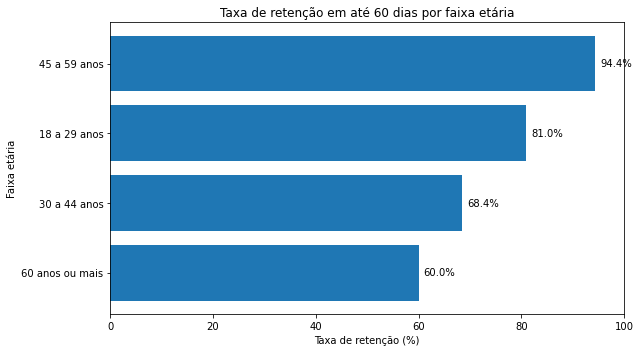

In [111]:
age_plot = retention_by_age_group.sort_values(
    "retention_60_rate",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    age_plot["age_group"].astype(str),
    age_plot["retention_60_rate"]
)

ax.set_title(
    "Taxa de retenção em até 60 dias por faixa etária"
)

ax.set_xlabel("Taxa de retenção (%)")
ax.set_ylabel("Faixa etária")
ax.set_xlim(0, 100)

for bar, rate in zip(
    bars,
    age_plot["retention_60_rate"]
):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

### Conclusão da retenção por faixa etária

A maior taxa de retenção em até 60 dias foi observada entre os pacientes de 45 a 59 anos. Nesse grupo, 17 dos 18 pacientes elegíveis realizaram o primeiro retorno, correspondendo a uma taxa de 94,44%.

Os pacientes de 18 a 29 anos apresentaram a segunda maior retenção, com 80,95%, enquanto o grupo de 30 a 44 anos registrou 68,42%.

A menor taxa de retenção em 60 dias foi identificada entre os pacientes com 60 anos ou mais, com 60,00%. Mesmo após 90 dias, esse grupo permaneceu com a menor taxa, alcançando 70,00%.

Os resultados indicam que os pacientes com 60 anos ou mais podem representar um grupo prioritário para ações de acompanhamento, como lembretes, contato após a primeira consulta e facilitação do agendamento do retorno.

Entretanto, as diferenças observadas não devem ser interpretadas como uma relação causal entre idade e retenção. Outros fatores, como objetivo nutricional, profissional responsável, cidade e frequência de consultas, também podem influenciar a continuidade do acompanhamento.


## 13. Comparação da retenção entre perfis

Para manter o mesmo critério em todas as comparações, será criada uma função
que calcula a retenção acumulada em 30, 60 e 90 dias para qualquer variável de
segmentação.

O denominador de cada período considera somente pacientes com tempo de
acompanhamento suficiente para completar a respectiva janela.


In [112]:
def calculate_retention_by_group(data, group_column):
    """Calcula retenção acumulada por grupo em 30, 60 e 90 dias."""

    base_columns = [
        "patient_id",
        group_column,
        "first_return_date",
        "days_to_first_return",
        "available_follow_up_days",
        "retained_30_days",
        "retained_60_days",
        "retained_90_days"
    ]

    retention_data = data[base_columns].copy()

    summary = (
        retention_data
        .groupby(group_column, observed=True, dropna=False)
        .agg(
            total_patients=("patient_id", "nunique"),
            patients_without_return=(
                "first_return_date",
                lambda series: series.isna().sum()
            ),
            median_days_to_return=(
                "days_to_first_return",
                "median"
            )
        )
        .reset_index()
    )

    for period in [30, 60, 90]:
        eligible_data = retention_data[
            retention_data["available_follow_up_days"] >= period
        ]

        period_summary = (
            eligible_data
            .groupby(group_column, observed=True, dropna=False)
            .agg(
                **{
                    f"eligible_{period}_days": (
                        "patient_id",
                        "nunique"
                    ),
                    f"retained_{period}_days": (
                        f"retained_{period}_days",
                        "sum"
                    )
                }
            )
            .reset_index()
        )

        period_summary[f"retention_{period}_rate"] = (
            period_summary[f"retained_{period}_days"]
            / period_summary[f"eligible_{period}_days"]
            * 100
        ).round(2)

        summary = summary.merge(
            period_summary,
            on=group_column,
            how="left",
            validate="one_to_one"
        )

    summary["without_return_rate"] = (
        summary["patients_without_return"]
        / summary["total_patients"]
        * 100
    ).round(2)

    summary["median_days_to_return"] = (
        summary["median_days_to_return"]
        .round(1)
    )

    return summary.sort_values(
        "retention_60_rate",
        ascending=False
    ).reset_index(drop=True)


def plot_retention_60(summary, group_column, title, y_label):
    plot_data = summary.sort_values(
        "retention_60_rate",
        ascending=True
    )

    fig, ax = plt.subplots(
        figsize=(9, max(4.5, len(plot_data) * 0.7))
    )

    bars = ax.barh(
        plot_data[group_column].astype(str),
        plot_data["retention_60_rate"]
    )

    ax.set_title(title)
    ax.set_xlabel("Taxa de retenção em até 60 dias (%)")
    ax.set_ylabel(y_label)
    ax.set_xlim(0, 100)

    for bar, rate in zip(
        bars,
        plot_data["retention_60_rate"]
    ):
        ax.text(
            min(bar.get_width() + 1, 98),
            bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}%",
            va="center"
        )

    plt.tight_layout()
    plt.show()


### 13.1 Retenção por gênero

A comparação por gênero será feita com base no primeiro retorno atendido.
Como os grupos podem possuir tamanhos diferentes, a interpretação deve
considerar tanto a taxa quanto o número de pacientes elegíveis.


,gender,total_patients,patients_without_return,median_days_to_return,eligible_30_days,retained_30_days,retention_30_rate,eligible_60_days,retained_60_days,retention_60_rate,eligible_90_days,retained_90_days,retention_90_rate,without_return_rate
0,M,32,2,38.00,32,9,28.12,32,25,78.12,32,28,87.50,6.25
1,F,46,7,45.00,46,11,23.91,46,34,73.91,46,36,78.26,15.22


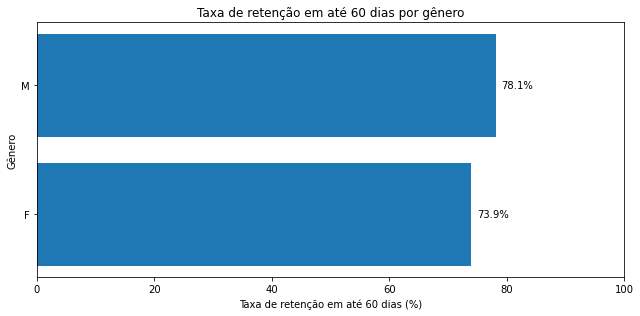

In [113]:
retention_by_gender = calculate_retention_by_group(
    retention_profile,
    "gender"
)

display(retention_by_gender)

plot_retention_60(
    retention_by_gender,
    "gender",
    "Taxa de retenção em até 60 dias por gênero",
    "Gênero"
)


### 13.2 Retenção por objetivo nutricional

Esta análise permite identificar quais objetivos apresentam maior continuidade
do acompanhamento e quais grupos podem precisar de estratégias específicas de
engajamento.


,goal,total_patients,patients_without_return,median_days_to_return,eligible_30_days,retained_30_days,retention_30_rate,eligible_60_days,retained_60_days,retention_60_rate,eligible_90_days,retained_90_days,retention_90_rate,without_return_rate
0,Emagrecimento,15,0,41.00,15,6,40.00,15,14,93.33,15,15,100.00,0.00
1,Diabetes,16,1,34.00,16,6,37.50,16,12,75.00,16,13,81.25,6.25
2,Reeducação Alimentar,20,3,46.00,20,4,20.00,20,15,75.00,20,16,80.00,15.00
3,Nutrição Esportiva,13,3,39.50,13,2,15.38,13,9,69.23,13,10,76.92,23.08
4,Bariátrica,14,2,56.50,14,2,14.29,14,9,64.29,14,10,71.43,14.29


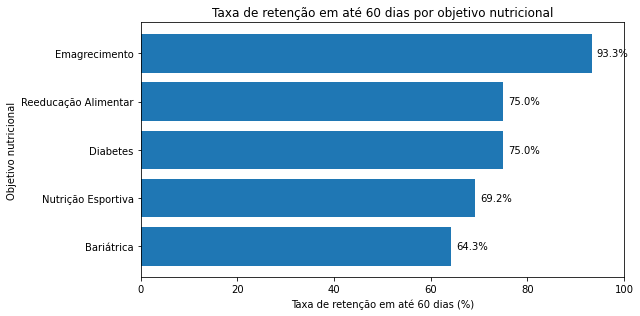

In [114]:
retention_by_goal = calculate_retention_by_group(
    retention_profile,
    "goal"
)

display(retention_by_goal)

plot_retention_60(
    retention_by_goal,
    "goal",
    "Taxa de retenção em até 60 dias por objetivo nutricional",
    "Objetivo nutricional"
)


### 13.3 Retenção por cidade

A comparação por cidade pode sinalizar possíveis barreiras de deslocamento,
acesso ou disponibilidade de agenda. Entretanto, a base não contém distância,
tempo de viagem ou modalidade de atendimento, portanto os resultados devem ser
interpretados como associações exploratórias.


,city,total_patients,patients_without_return,median_days_to_return,eligible_30_days,retained_30_days,retention_30_rate,eligible_60_days,retained_60_days,retention_60_rate,eligible_90_days,retained_90_days,retention_90_rate,without_return_rate
0,São Paulo,23,0,46.00,23,6,26.09,23,21,91.30,23,22,95.65,0.00
1,Osasco,14,0,48.50,14,3,21.43,14,12,85.71,14,14,100.00,0.00
2,Santo André,8,0,38.00,8,2,25.00,8,6,75.00,8,8,100.00,0.00
3,Guarulhos,13,3,43.50,13,2,15.38,13,8,61.54,13,8,61.54,23.08
4,São Bernardo,20,6,30.50,20,7,35.00,20,12,60.00,20,12,60.00,30.00


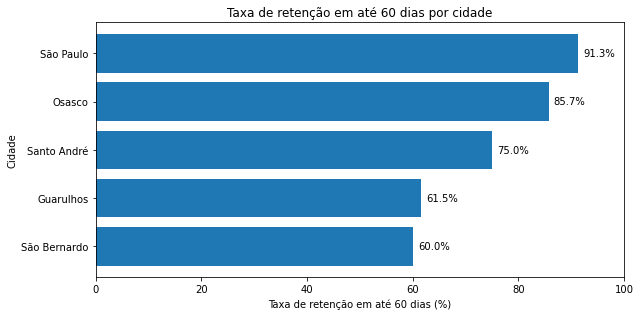

In [115]:
retention_by_city = calculate_retention_by_group(
    retention_profile,
    "city"
)

display(retention_by_city)

plot_retention_60(
    retention_by_city,
    "city",
    "Taxa de retenção em até 60 dias por cidade",
    "Cidade"
)


### 13.4 Retenção por nutricionista da primeira consulta

A retenção será atribuída ao profissional responsável pela primeira consulta
atendida. Esse critério evita contar o mesmo paciente para vários
nutricionistas.

Os resultados não devem ser interpretados automaticamente como efeito causal
do profissional, pois o perfil dos pacientes e a especialidade também podem
influenciar a continuidade.


,nutritionist_name,total_patients,patients_without_return,median_days_to_return,eligible_30_days,retained_30_days,retention_30_rate,eligible_60_days,retained_60_days,retention_60_rate,eligible_90_days,retained_90_days,retention_90_rate,without_return_rate
0,Juliana Rocha,9,0,57.00,9,0,0.00,9,9,100.00,9,9,100.00,0.00
1,Marina Costa,20,2,29.50,20,9,45.00,20,17,85.00,20,18,90.00,10.00
2,Ana Lima,20,1,45.00,20,2,10.00,20,16,80.00,20,16,80.00,5.00
3,Fernanda Alves,19,4,34.00,19,7,36.84,19,14,73.68,19,15,78.95,21.05
4,Carlos Souza,10,2,83.00,10,2,20.00,10,3,30.00,10,6,60.00,20.00


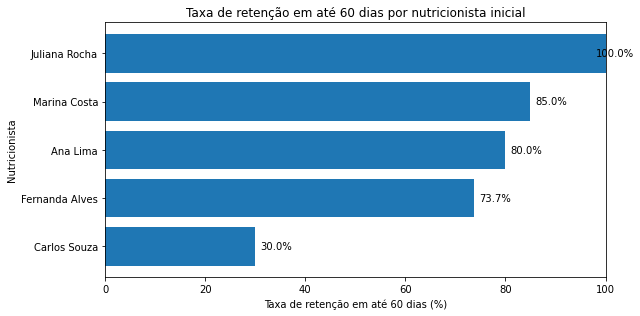

In [116]:
retention_by_nutritionist = calculate_retention_by_group(
    retention_profile,
    "nutritionist_name"
)

display(retention_by_nutritionist)

plot_retention_60(
    retention_by_nutritionist,
    "nutritionist_name",
    "Taxa de retenção em até 60 dias por nutricionista inicial",
    "Nutricionista"
)


## 14. Intervalo entre consultas realizadas

Além do tempo até o primeiro retorno, será calculado o intervalo entre todas as
consultas atendidas consecutivas de cada paciente. Esse indicador responde à
pergunta sobre a frequência real do acompanhamento ao longo do tratamento.


In [117]:
attended_history = (
    analytical_table[
        analytical_table["attended"] == 1
    ]
    [
        [
            "patient_id",
            "consultation_id",
            "consultation_date",
            "consultation_type"
        ]
    ]
    .sort_values(
        [
            "patient_id",
            "consultation_date",
            "consultation_id"
        ]
    )
    .copy()
)

attended_history["days_since_previous_attended"] = (
    attended_history
    .groupby("patient_id")["consultation_date"]
    .diff()
    .dt.days
)

valid_intervals = attended_history[
    attended_history["days_since_previous_attended"] > 0
]["days_since_previous_attended"]

interval_summary = (
    valid_intervals
    .describe()
    .to_frame("days_between_attended_consultations")
)

display(interval_summary)

print(
    "Intervalo médio entre consultas atendidas:",
    round(valid_intervals.mean(), 2),
    "dias"
)

print(
    "Intervalo mediano entre consultas atendidas:",
    round(valid_intervals.median(), 2),
    "dias"
)

print(
    "Intervalos iguais ou menores que zero:",
    (
        attended_history["days_since_previous_attended"]
        .dropna()
        .le(0)
        .sum()
    )
)


,days_between_attended_consultations
count,210.00
mean,43.66
std,20.22
min,15.00
25%,29.25
50%,41.50
75%,55.00
max,124.00


Intervalo médio entre consultas atendidas: 43.66 dias
Intervalo mediano entre consultas atendidas: 41.5 dias
Intervalos iguais ou menores que zero: 0


## 15. Desempenho operacional por nutricionista

Serão comparados o volume de consultas, o comparecimento e a retenção em
60 dias. A taxa de comparecimento considera todas as consultas atribuídas ao
profissional, enquanto a retenção considera o nutricionista da primeira
consulta atendida.


In [118]:
nutritionist_performance = (
    analytical_table
    .groupby(
        [
            "nutritionist_id",
            "nutritionist_name",
            "specialty"
        ],
        as_index=False
    )
    .agg(
        scheduled_consultations=(
            "consultation_id",
            "nunique"
        ),
        attended_consultations=(
            "attended",
            "sum"
        ),
        registered_revenue=(
            "amount_brl",
            "sum"
        )
    )
)

nutritionist_performance["missed_consultations"] = (
    nutritionist_performance["scheduled_consultations"]
    - nutritionist_performance["attended_consultations"]
)

nutritionist_performance["attendance_rate"] = (
    nutritionist_performance["attended_consultations"]
    / nutritionist_performance["scheduled_consultations"]
    * 100
).round(2)

retention_columns = retention_by_nutritionist[
    [
        "nutritionist_name",
        "eligible_60_days",
        "retained_60_days",
        "retention_60_rate",
        "median_days_to_return"
    ]
]

nutritionist_performance = (
    nutritionist_performance
    .merge(
        retention_columns,
        on="nutritionist_name",
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        "retention_60_rate",
        ascending=False
    )
)

display(nutritionist_performance)


,nutritionist_id,nutritionist_name,specialty,scheduled_consultations,attended_consultations,registered_revenue,missed_consultations,attendance_rate,eligible_60_days,retained_60_days,retention_60_rate,median_days_to_return
4,5,Juliana Rocha,Clínica Geral,69,56,10180,13,81.16,9,9,100.00,57.00
3,4,Marina Costa,Esportiva,90,71,13600,19,78.89,20,17,85.00,29.50
0,1,Ana Lima,Emagrecimento,83,66,12660,17,79.52,20,16,80.00,45.00
2,3,Fernanda Alves,Bariátrica,77,61,11620,16,79.22,19,14,73.68,34.00
1,2,Carlos Souza,Diabetes,67,53,9980,14,79.10,10,3,30.00,83.00


## 16. Identificação exploratória de risco de abandono

Como a base é simulada e não contém um indicador oficial de abandono, será criado um sistema de pontuação baseado em critérios claros. Ele não representa um modelo preditivo.

O escore considera ausência de primeiro retorno, retorno muito tardio,
proporção elevada de faltas e longo período desde a última consulta atendida.
Seu objetivo é priorizar pacientes para contato e acompanhamento.


In [119]:
patient_activity = (
    analytical_table
    .assign(
        attended_date=analytical_table[
            "consultation_date"
        ].where(
            analytical_table["attended"] == 1
        )
    )
    .groupby("patient_id", as_index=False)
    .agg(
        scheduled_consultations=(
            "consultation_id",
            "nunique"
        ),
        attended_consultations=(
            "attended",
            "sum"
        ),
        last_scheduled_date=(
            "consultation_date",
            "max"
        ),
        last_attended_date=(
            "attended_date",
            "max"
        )
    )
)

patient_activity["missed_consultations"] = (
    patient_activity["scheduled_consultations"]
    - patient_activity["attended_consultations"]
)

patient_activity["absence_rate"] = (
    patient_activity["missed_consultations"]
    / patient_activity["scheduled_consultations"]
    * 100
).round(2)

patient_activity["days_since_last_attended"] = (
    data_end_date
    - patient_activity["last_attended_date"]
).dt.days

abandonment_risk = (
    retention_profile
    .merge(
        patient_activity,
        on="patient_id",
        how="left",
        validate="one_to_one"
    )
)

abandonment_risk["risk_score"] = 0

abandonment_risk["risk_score"] += np.where(
    abandonment_risk["first_return_date"].isna()
    & (
        abandonment_risk["available_follow_up_days"]
        >= 60
    ),
    2,
    0
)

abandonment_risk["risk_score"] += np.where(
    abandonment_risk["days_to_first_return"] > 90,
    1,
    0
)

abandonment_risk["risk_score"] += np.where(
    abandonment_risk["absence_rate"] >= 50,
    1,
    0
)

abandonment_risk["risk_score"] += np.where(
    abandonment_risk["days_since_last_attended"] >= 90,
    1,
    0
)

abandonment_risk["risk_level"] = pd.cut(
    abandonment_risk["risk_score"],
    bins=[-1, 1, 3, np.inf],
    labels=[
        "Baixo",
        "Médio",
        "Alto"
    ]
)


def describe_risk(row):
    reasons = []

    if (
        pd.isna(row["first_return_date"])
        and row["available_follow_up_days"] >= 60
    ):
        reasons.append("sem primeiro retorno em 60 dias")

    if (
        pd.notna(row["days_to_first_return"])
        and row["days_to_first_return"] > 90
    ):
        reasons.append("primeiro retorno após 90 dias")

    if row["absence_rate"] >= 50:
        reasons.append("taxa de ausência igual ou superior a 50%")

    if row["days_since_last_attended"] >= 90:
        reasons.append("90 dias ou mais desde a última consulta atendida")

    return "; ".join(reasons) if reasons else "sem sinal prioritário"


abandonment_risk["risk_reason"] = (
    abandonment_risk
    .apply(
        describe_risk,
        axis=1
    )
)

risk_summary = (
    abandonment_risk["risk_level"]
    .value_counts()
    .reindex(
        [
            "Alto",
            "Médio",
            "Baixo"
        ]
    )
    .fillna(0)
    .astype(int)
    .rename_axis("risk_level")
    .reset_index(name="patients")
)

display(risk_summary)

priority_patients = (
    abandonment_risk[
        abandonment_risk["risk_level"].isin(
            [
                "Alto",
                "Médio"
            ]
        )
    ]
    [
        [
            "patient_id",
            "age",
            "gender",
            "city",
            "goal",
            "nutritionist_name",
            "scheduled_consultations",
            "missed_consultations",
            "absence_rate",
            "days_to_first_return",
            "days_since_last_attended",
            "risk_score",
            "risk_level",
            "risk_reason"
        ]
    ]
    .sort_values(
        [
            "risk_score",
            "absence_rate",
            "days_since_last_attended"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
)

display(priority_patients.head(20))


,risk_level,patients
0,Alto,1
1,Médio,14
2,Baixo,63


,patient_id,age,gender,city,goal,nutritionist_name,scheduled_consultations,missed_consultations,absence_rate,days_to_first_return,days_since_last_attended,risk_score,risk_level,risk_reason
22,27,26,F,São Bernardo,Reeducação Alimentar,Fernanda Alves,2,1,50.00,NaN,371.00,4,Alto,sem primeiro retorno em 60 dias; taxa de ausên...
53,66,71,F,São Paulo,Diabetes,Ana Lima,4,2,50.00,124.00,95.00,3,Médio,primeiro retorno após 90 dias; taxa de ausênci...
4,5,32,F,São Bernardo,Diabetes,Marina Costa,1,0,0.00,NaN,475.00,3,Médio,sem primeiro retorno em 60 dias; 90 dias ou ma...
50,62,30,F,São Bernardo,Nutrição Esportiva,Marina Costa,1,0,0.00,NaN,397.00,3,Médio,sem primeiro retorno em 60 dias; 90 dias ou ma...
62,78,74,F,São Bernardo,Reeducação Alimentar,Fernanda Alves,1,0,0.00,NaN,341.00,3,Médio,sem primeiro retorno em 60 dias; 90 dias ou ma...
37,45,67,F,Guarulhos,Nutrição Esportiva,Fernanda Alves,1,0,0.00,NaN,331.00,3,Médio,sem primeiro retorno em 60 dias; 90 dias ou ma...
21,26,43,M,Guarulhos,Bariátrica,Carlos Souza,1,0,0.00,NaN,295.00,3,Médio,sem primeiro retorno em 60 dias; 90 dias ou ma...
23,28,34,M,São Bernardo,Nutrição Esportiva,Ana Lima,1,0,0.00,NaN,292.00,3,Médio,sem primeiro retorno em 60 dias; 90 dias ou ma...
67,86,74,F,Guarulhos,Bariátrica,Carlos Souza,1,0,0.00,NaN,287.00,3,Médio,sem primeiro retorno em 60 dias; 90 dias ou ma...
33,40,66,F,São Bernardo,Reeducação Alimentar,Fernanda Alves,1,0,0.00,NaN,285.00,3,Médio,sem primeiro retorno em 60 dias; 90 dias ou ma...


## 17. Síntese executiva

Nesta etapa, os principais resultados da análise são consolidados em uma visão
executiva. O objetivo é transformar os indicadores calculados em informações
úteis para a gestão da clínica, sem atribuir causalidade a associações
observadas em uma base exploratória e simulada.


In [120]:
# Consolidar os principais indicadores do projeto

def retention_rate_for_period(period):
    eligible = (
        patient_retention["available_follow_up_days"]
        >= period
    )

    retained = patient_retention.loc[
        eligible,
        f"retained_{period}_days"
    ].sum()

    total_eligible = eligible.sum()

    return (
        retained / total_eligible * 100
        if total_eligible > 0
        else np.nan
    )


risk_counts = (
    abandonment_risk["risk_level"]
    .value_counts()
)

executive_kpis = pd.DataFrame(
    {
        "Indicador": [
            "Pacientes cadastrados",
            "Consultas agendadas",
            "Taxa de comparecimento",
            "Taxa de ausência",
            "Receita total registrada",
            "Valor associado a ausências",
            "Retenção em 30 dias",
            "Retenção em 60 dias",
            "Retenção em 90 dias",
            "Intervalo médio entre consultas",
            "Intervalo mediano entre consultas",
            "Pacientes com risco alto",
            "Pacientes com risco médio"
        ],
        "Resultado": [
            analytical_table["patient_id"].nunique(),
            analytical_table["consultation_id"].nunique(),
            f"{analytical_table['attended'].mean() * 100:.2f}%",
            f"{(1 - analytical_table['attended'].mean()) * 100:.2f}%",
            (
                f"R$ {analytical_table['amount_brl'].sum():,.0f}"
                .replace(",", ".")
            ),
            (
                "R$ "
                f"{analytical_table.loc[analytical_table['attended'] == 0, 'amount_brl'].sum():,.0f}"
                .replace(",", ".")
            ),
            f"{retention_rate_for_period(30):.2f}%",
            f"{retention_rate_for_period(60):.2f}%",
            f"{retention_rate_for_period(90):.2f}%",
            f"{valid_intervals.mean():.2f} dias",
            f"{valid_intervals.median():.1f} dias",
            int(risk_counts.get("Alto", 0)),
            int(risk_counts.get("Médio", 0))
        ]
    }
)

display(executive_kpis)


,Indicador,Resultado
0,Pacientes cadastrados,100
1,Consultas agendadas,386
2,Taxa de comparecimento,79.53%
3,Taxa de ausência,20.47%
4,Receita total registrada,R$ 58.040
5,Valor associado a ausências,R$ 11.940
6,Retenção em 30 dias,25.64%
7,Retenção em 60 dias,75.64%
8,Retenção em 90 dias,82.05%
9,Intervalo médio entre consultas,43.66 dias


### 17.1 Principais resultados

A clínica registrou **386 consultas para 100 pacientes**, com **307 comparecimentos e 79 ausências**. A taxa geral de comparecimento foi de **79,53%**, enquanto a taxa de ausência alcançou **20,47%**. 

A receita total registrada foi de **R$ 58.040**.

Desse valor, **R$ 11.940 (20,57%)** estão associados a consultas sem comparecimento. Como a base possui um pagamento vinculado a cada consulta, esse montante não pode ser interpretado automaticamente como perda financeira. Ele representa o valor registrado nas consultas ausentes, sem informação sobre cobrança, reembolso ou cancelamento.

Entre os **78 pacientes que compareceram à primeira consulta**, 69 realizaram ao menos um retorno e nove não retornaram. A retenção acumulada foi de **25,64% em 30 dias**, **75,64% em 60 dias** e **82,05% em 90 dias**.

A maior concentração de primeiros retornos ocorreu entre **31 e 60 dias**: 39 pacientes, equivalentes a 50% da base elegível. O tempo médio até o primeiro retorno foi de **46,86 dias**, com mediana de **44 dias**.

Considerando todos os intervalos entre consultas atendidas consecutivas, a média foi de **43,66 dias** e a mediana de **41,5 dias**. Esses resultados indicam que o acompanhamento ocorre, em geral, em intervalos próximos de seis semanas.


### 17.2 Retenção segundo o perfil dos pacientes

A faixa etária de **45 a 59 anos** apresentou a maior retenção em até 60 dias,
com **94,44%**. O menor resultado ocorreu entre pacientes com **60 anos ou
mais**, com **60,00%**.

A diferença por gênero foi moderada. Pacientes do gênero masculino
apresentaram retenção de **78,12% em 60 dias**, enquanto pacientes do gênero
feminino registraram **73,91%**. A diferença deve ser interpretada com cautela,
pois os grupos possuem tamanhos distintos.

Entre os objetivos nutricionais, **Emagrecimento** apresentou a maior retenção
em 60 dias, com **93,33%**. O menor resultado foi observado em
**Bariátrica**, com **64,29%**. Nutrição Esportiva também ficou abaixo da taxa
geral, com **69,23%**.

Na comparação geográfica, **São Paulo** apresentou retenção de **91,30% em
60 dias**, seguida por Osasco, com **85,71%**. Os menores resultados foram
observados em **Guarulhos, com 61,54%**, e **São Bernardo, com 60,00%**.
São Bernardo também concentrou seis dos nove pacientes sem retorno.


### 17.3 Desempenho entre nutricionistas

As taxas de comparecimento dos cinco profissionais foram semelhantes, variando
entre **78,89% e 81,16%**. Isso indica uma relativa estabilidade operacional no
comparecimento, apesar das diferenças de volume de consultas.

Na retenção em até 60 dias, **Juliana Rocha** apresentou 100%, porém o resultado
corresponde a apenas nove pacientes elegíveis. **Marina Costa** registrou
85,00%, **Ana Lima** 80,00%, **Fernanda Alves** 73,68% e
**Carlos Souza** 30,00%.

Carlos Souza também apresentou o maior tempo mediano até o primeiro retorno,
com **83 dias**. Entretanto, esses resultados não devem ser tratados
isoladamente como avaliação de desempenho individual. O perfil dos pacientes,
a especialidade, o objetivo nutricional e o tamanho de cada grupo podem
influenciar a retenção observada.


### 17.4 Pacientes com risco de abandono

O escore exploratório classificou **um paciente com risco alto**, **14 com
risco médio** e **63 com risco baixo**.

Os critérios considerados foram:

- ausência de primeiro retorno após pelo menos 60 dias de acompanhamento;
- primeiro retorno realizado após 90 dias;
- taxa de ausência igual ou superior a 50%;
- 90 dias ou mais desde a última consulta atendida.

A classificação funciona como instrumento de priorização operacional. Ela não
representa uma previsão estatística e não deve ser utilizada como diagnóstico
definitivo de abandono.


## 18. Recomendações de negócio

### 18.1 Antecipar o primeiro retorno

Somente 25,64% dos pacientes retornaram em até 30 dias, enquanto metade dos
pacientes realizou o primeiro retorno entre 31 e 60 dias. A clínica pode
estimular o agendamento da próxima consulta ainda no primeiro atendimento,
preferencialmente dentro de uma janela clínica previamente definida.

### 18.2 Criar uma rotina de acompanhamento de risco

Os 15 pacientes classificados com risco alto ou médio devem formar uma lista
prioritária de contato. A clínica pode estruturar lembretes, mensagens de
acompanhamento e tentativas de reagendamento, registrando o resultado de cada
ação.

### 18.3 Desenvolver ações segmentadas

Pacientes com 60 anos ou mais, pacientes de acompanhamento bariátrico e
pacientes de Guarulhos e São Bernardo apresentaram menor retenção. Recomenda-se
investigar barreiras específicas desses grupos, como deslocamento,
disponibilidade de horário, frequência indicada, modalidade de atendimento ou
necessidade de suporte adicional.

### 18.4 Investigar diferenças entre profissionais

A retenção associada a Carlos Souza ficou abaixo dos demais resultados, mas a
comparação deve incluir o perfil dos pacientes e a especialidade. Uma análise
mais detalhada pode verificar distribuição por objetivo, idade, cidade,
quantidade de pacientes e intervalo recomendado entre consultas antes de
propor qualquer ação.

### 18.5 Reduzir ausências

A taxa de ausência de 20,47% justifica a adoção de confirmação automática,
lembrete antecipado e uma política clara de cancelamento e reagendamento.
Também é importante registrar os motivos das faltas para distinguir problemas
de agenda, acesso, comunicação ou desistência.

### 18.6 Monitorar indicadores em um dashboard

Os principais indicadores devem ser acompanhados periodicamente:

- taxa de comparecimento e ausência;
- retenção em 30, 60 e 90 dias;
- intervalo médio entre consultas;
- pacientes sem retorno;
- pacientes por nível de risco;
- retenção por perfil e nutricionista;
- valor registrado em consultas atendidas e ausentes.


## 19. Limitações da análise

Este projeto utiliza dados simulados, portanto os resultados demonstram a
aplicação da metodologia analítica e não representam uma clínica real.

A base também não contém informações sobre motivo da ausência, cancelamento,
reembolso, distância até a clínica, modalidade presencial ou on-line,
satisfação do paciente, evolução clínica ou canal de aquisição.

Os valores associados às consultas ausentes não podem ser tratados como perda
de receita, pois não existe informação sobre a efetiva cobrança.

O escore de risco é heurístico e transparente, mas não foi treinado nem
validado como modelo preditivo.

Por fim, alguns grupos possuem poucos pacientes. As diferenças observadas são
exploratórias e não permitem estabelecer relações causais.


## 20. Conclusão final

A análise mostra que a clínica possui uma taxa de comparecimento próxima de
80% e alcança retenção acumulada de 75,64% em 60 dias e 82,05% em 90 dias.
Apesar disso, a retenção nos primeiros 30 dias ainda é baixa, indicando que a
principal oportunidade está em antecipar o primeiro retorno e fortalecer o
acompanhamento logo após a consulta inicial.

Também foram identificadas diferenças relevantes entre faixas etárias,
objetivos nutricionais, cidades e profissionais. Esses resultados permitem
direcionar ações específicas, mas precisam ser analisados juntamente com o
tamanho e as características de cada grupo.

A criação de uma rotina de contato para pacientes com risco alto ou médio,
combinada com lembretes, reagendamento e monitoramento por dashboard, pode
apoiar a continuidade do tratamento e melhorar a gestão da agenda.

O projeto demonstra uma abordagem completa de análise de dados, integrando
**Python, SQL, análise exploratória, indicadores de negócio, segmentação de
pacientes e identificação de risco**. Como entrega final, os principais
indicadores foram consolidados em um **dashboard interativo no Power BI**,
transformando os resultados em uma ferramenta visual de acompanhamento e
apoio à tomada de decisão.


In [121]:
from pathlib import Path

# Criar pasta para os arquivos do Power BI
output_folder = Path("powerbi_exports")
output_folder.mkdir(exist_ok=True)

# Tabela principal de consultas
analytical_table.to_csv(
    output_folder / "consultations_analytical.csv",
    index=False,
    encoding="utf-8-sig"
)

# Retenção e perfil dos pacientes
retention_profile.to_csv(
    output_folder / "patient_retention.csv",
    index=False,
    encoding="utf-8-sig"
)

# Classificação de risco de abandono
abandonment_risk.to_csv(
    output_folder / "patient_risk.csv",
    index=False,
    encoding="utf-8-sig"
)

# Desempenho dos nutricionistas
nutritionist_performance.to_csv(
    output_folder / "nutritionist_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos exportados para a pasta powerbi_exports:")
for file in output_folder.iterdir():
    print("-", file.name)

Arquivos exportados para a pasta powerbi_exports:
- consultations_analytical.csv
- patient_risk.csv
- patient_retention.csv
- nutritionist_performance.csv


In [122]:
import shutil

shutil.make_archive(
    "powerbi_exports",
    "zip",
    "powerbi_exports"
)

print("Arquivo powerbi_exports.zip criado com sucesso.")

Arquivo powerbi_exports.zip criado com sucesso.
